# 04 · Baseline models: ทำนายระดับน้ำ X.44 ล่วงหน้า 1–5 วัน

ใช้ตารางจาก `03_feature_engineering.ipynb` เทียบโมเดล 5 แบบ แยกโมเดลต่อ horizon (h = 1…5 วัน)

| โมเดล | ทำนายอะไร | ทำไมถึงลอง |
|---|---|---|
| **persistence** | ระดับ t+h = ระดับวันนี้ | เกณฑ์ขั้นต่ำ |
| **ridge_delta** | การเปลี่ยนแปลงของระดับน้ำ (linear) | extrapolate เกินช่วง train ได้ |
| **lgbm_level** | ระดับน้ำตรงๆ (LightGBM) | แบบที่ทำกันทั่วไป — คาดว่าติดเพดาน |
| **lgbm_delta** | การเปลี่ยนแปลง (LightGBM) | ให้ต้นไม้เรียนการขึ้น/ลงแทนระดับ |
| **lgbm_linear_delta** | การเปลี่ยนแปลง (LightGBM `linear_tree`) | ต้นไม้ที่มีสมการเส้นตรงในใบ extrapolate ได้ |

**ตัวชี้วัด**
- **MAE ทุกวัน** — ภาพรวม แต่ถูกวันปกติ (น้ำนิ่ง) ครอบงำ
- **MAE วันน้ำหลาก** — เฉพาะวันที่ระดับจริง ≥ 4 ม. ← ตัวชี้วัดหลัก
- **การเตือนภัย** — ทำนาย ≥ 7.40 ม. (ท่วมพื้นที่ลุ่มต่ำ) ได้ถูกวันกี่วัน / เตือนผิดกี่วัน

**ขั้นตอน:** เลือก hyperparameter ด้วย validation (2024) → เทรนใหม่บน train+validation → วัดผลจริงบน test (2025–2026) ครั้งเดียว

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy
import pandas
from IPython.display import display

from mojito import config, evaluation, features, models

warnings.filterwarnings("ignore", category=UserWarning)
plt.rcParams.update({
    "font.family": ["Noto Sans Thai", "DejaVu Sans"],
    "figure.figsize": (12, 4),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
MODEL_COLORS = {
    "persistence": "#999999", "ridge_delta": "#4c72b0", "lgbm_level": "#dd8452",
    "lgbm_delta": "#55a868", "lgbm_linear_delta": "#8172b2",
}
HIGH_WATER_M = evaluation.HIGH_WATER_M
FLOOD_M = evaluation.FLOOD_M

table = pandas.read_parquet(config.DATA_DIR / "processed" / "features_daily.parquet")
FEATURES = features.feature_columns(table)
train = table[table["split"] == "train"]
validation = table[table["split"] == "validation"]
train_validation = table[table["split"] != "test"]
test = table[table["split"] == "test"]
print(f"{len(FEATURES)} features | train {len(train)} วัน | validation {len(validation)} | test {len(test)}")

46 features | train 1418 วัน | validation 366 | test 642


In [2]:
scores = evaluation.scores
persistence = evaluation.persistence


def fit_and_predict(name, params, fit_frame, eval_frame, horizon, feature_names=FEATURES):
    model = models.HorizonModel(name, horizon, feature_names, params).fit(fit_frame)
    return model, model.predict(eval_frame)

## 1 · เลือก hyperparameter ด้วย validation (2024)
เทรนบน train (2020–2023) วัดบน validation ที่มีเหตุการณ์ใกล้ล้นตลิ่ง พ.ย. 2567 (7.26 ม.)
เลือกค่าที่ให้ **MAE วันน้ำหลาก เฉลี่ยทุก horizon** ต่ำสุด

⚠️ validation มีวันน้ำหลากแค่ 5–6 วัน การเลือกจึงมีความไม่แน่นอนสูง — ใช้ grid เล็กๆ เพื่อไม่ให้ overfit กับ validation

In [3]:
GRID = {
    "ridge_delta": [{"alpha": a} for a in (1, 10, 100)],
    "lgbm_level": [{"num_leaves": n} for n in (7, 15)],
    "lgbm_delta": [{"num_leaves": n, "min_child_samples": m} for n in (7, 15, 31) for m in (10, 30)],
    "lgbm_linear_delta": [{"num_leaves": n} for n in (7, 15)],
}

tuning = []
for name, candidates in GRID.items():
    for params in candidates:
        per_horizon = [
            scores(fit_and_predict(name, params, train, validation, h)[1], validation, h)
            for h in features.HORIZONS
        ]
        tuning.append({
            "model": name, "params": params,
            "MAE วันน้ำหลาก (เฉลี่ย h)": numpy.mean([s["MAE วันน้ำหลาก"] for s in per_horizon]),
            "MAE ทุกวัน (เฉลี่ย h)": numpy.mean([s["MAE ทุกวัน"] for s in per_horizon]),
        })
tuning = pandas.DataFrame(tuning)
best = tuning.loc[tuning.groupby("model")["MAE วันน้ำหลาก (เฉลี่ย h)"].idxmin()].set_index("model")
BEST_PARAMS = best["params"].to_dict()

persistence_validation = numpy.mean([scores(persistence(validation, h), validation, h)["MAE วันน้ำหลาก"] for h in features.HORIZONS])
print(f"persistence บน validation: MAE วันน้ำหลาก (เฉลี่ย h) = {persistence_validation:.2f} ม.")
best.round(3)

persistence บน validation: MAE วันน้ำหลาก (เฉลี่ย h) = 3.30 ม.


,params,MAE วันน้ำหลาก (เฉลี่ย h),MAE ทุกวัน (เฉลี่ย h)
model,,,
lgbm_delta,"{'num_leaves': 7, 'min_child_samples': 10}",2.555,0.390
lgbm_level,{'num_leaves': 15},3.228,0.354
lgbm_linear_delta,{'num_leaves': 7},2.589,0.368
ridge_delta,{'alpha': 1},2.330,0.327


## 2 · ผลบน test (2025–2026) — เทรนใหม่บน train + validation

In [4]:
results, predictions, fitted = [], {}, {}
for h in features.HORIZONS:
    predictions[("persistence", h)] = persistence(test, h)
    for name, params in BEST_PARAMS.items():
        fitted[(name, h)], predictions[(name, h)] = fit_and_predict(name, params, train_validation, test, h)
    for name in MODEL_COLORS:
        results.append({"model": name, "h": h, **scores(predictions[(name, h)], test, h)})
results = pandas.DataFrame(results)

for metric in ["MAE วันน้ำหลาก", "MAE ทุกวัน"]:
    display(results.pivot(index="model", columns="h", values=metric).loc[list(MODEL_COLORS)]
            .round(2).rename_axis(columns=f"{metric} (ม.) · h ="))

MAE วันน้ำหลาก (ม.) · h =,1,2,3,4,5
model,,,,,
persistence,1.35,2.51,3.61,4.24,4.78
ridge_delta,0.68,1.65,3.06,4.14,4.73
lgbm_level,2.47,2.80,3.91,4.97,5.68
lgbm_delta,0.86,1.87,3.36,4.49,5.18
lgbm_linear_delta,0.63,1.66,2.96,4.41,5.27


MAE ทุกวัน (ม.) · h =,1,2,3,4,5
model,,,,,
persistence,0.14,0.22,0.28,0.32,0.35
ridge_delta,0.10,0.17,0.25,0.31,0.35
lgbm_level,0.12,0.20,0.26,0.30,0.34
lgbm_delta,0.11,0.19,0.25,0.30,0.34
lgbm_linear_delta,0.10,0.17,0.24,0.29,0.33


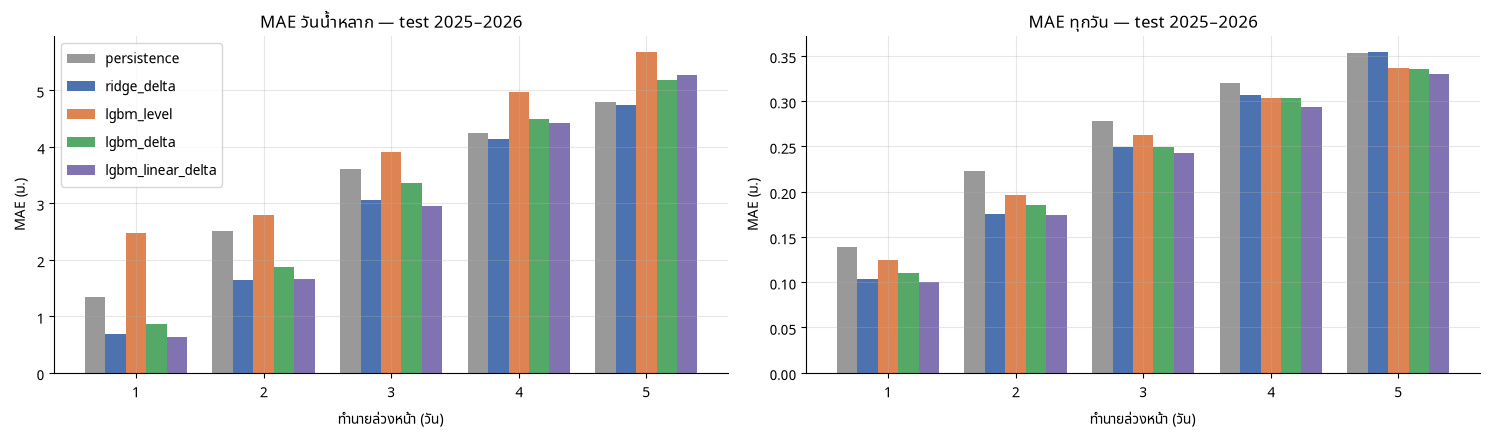

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
width = 0.16
for ax, metric in zip(axes, ["MAE วันน้ำหลาก", "MAE ทุกวัน"]):
    pivot = results.pivot(index="h", columns="model", values=metric)
    for i, name in enumerate(MODEL_COLORS):
        ax.bar(pivot.index + (i - 2) * width, pivot[name], width, label=name, color=MODEL_COLORS[name])
    ax.set_xlabel("ทำนายล่วงหน้า (วัน)")
    ax.set_ylabel("MAE (ม.)")
    ax.set_title(f"{metric} — test 2025–2026")
axes[0].legend()
plt.tight_layout()
plt.show()

## 3 · เหตุการณ์น้ำท่วม พ.ย. 2568: แต่ละโมเดลเห็นอะไรล่วงหน้า
เส้นแต่ละเส้นคือค่าที่โมเดล **ทำนายไว้ล่วงหน้า h วัน** สำหรับวันนั้น (เช่น h=3 ที่วันที่ 25 = ค่าที่ออกพยากรณ์เมื่อวันที่ 22)

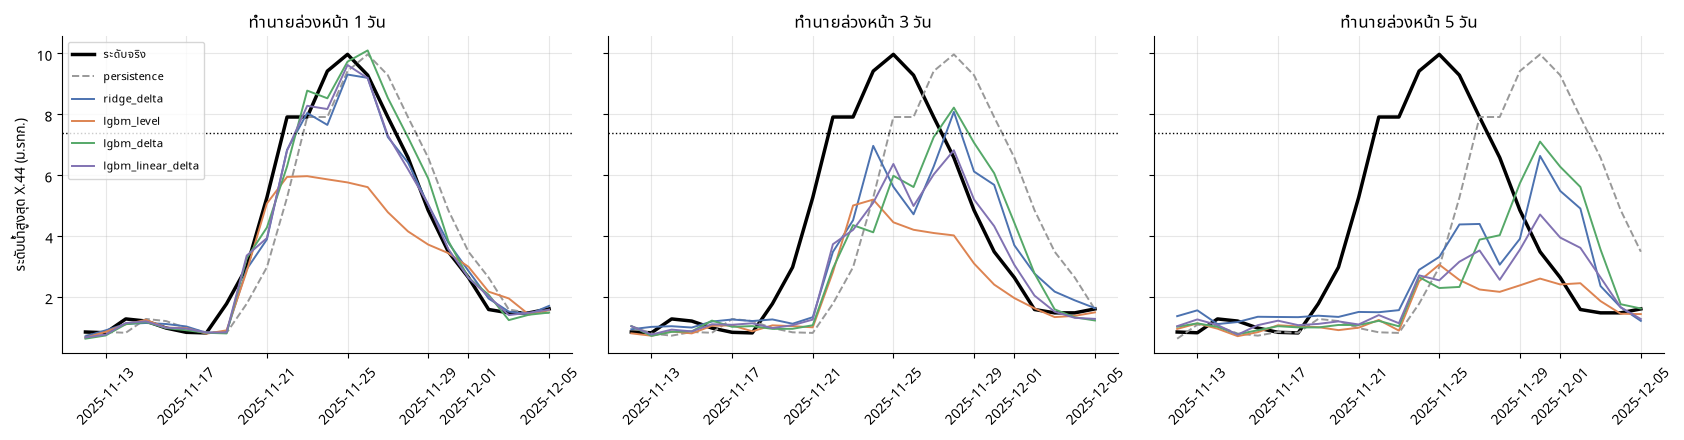

In [6]:
event = slice("2025-11-12", "2025-12-05")
actual = table["x44_max"].loc[event]

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5), sharey=True)
for ax, h in zip(axes, (1, 3, 5)):
    ax.plot(actual.index, actual, color="k", lw=2.5, label="ระดับจริง")
    for name in ["persistence", "ridge_delta", "lgbm_level", "lgbm_delta", "lgbm_linear_delta"]:
        shifted = predictions[(name, h)].copy()
        shifted.index = shifted.index + pandas.Timedelta(days=h)  # issued day t -> valid day t+h
        ax.plot(shifted.loc[event], color=MODEL_COLORS[name], lw=1.4, label=name,
                ls="--" if name == "persistence" else "-")
    ax.axhline(FLOOD_M, color="k", ls=":", lw=1)
    ax.set_title(f"ทำนายล่วงหน้า {h} วัน")
    ax.tick_params(axis="x", rotation=45)
axes[0].set_ylabel("ระดับน้ำสูงสุด X.44 (ม.รทก.)")
axes[0].legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

In [7]:
alerts = results.pivot_table(index="model", columns="h", values=["เตือนถูก", "เตือนผิด"]).loc[list(MODEL_COLORS)]
print(f"วันที่ระดับจริง ≥ {FLOOD_M} ม. ในชุด test: {results['วันท่วมจริง'].iloc[0]} วัน")
alerts

วันที่ระดับจริง ≥ 7.4 ม. ในชุด test: 6 วัน


เตือนถูก                     เตือนผิด                    
h                        1    2    3    4    5        1    2    3    4    5
model                                                                      
persistence            5.0  4.0  3.0  2.0  1.0      1.0  2.0  3.0  4.0  5.0
ridge_delta            4.0  3.0  0.0  0.0  0.0      0.0  0.0  1.0  0.0  0.0
lgbm_level             0.0  0.0  0.0  0.0  0.0      0.0  0.0  0.0  0.0  0.0
lgbm_delta             5.0  4.0  0.0  0.0  0.0      0.0  1.0  1.0  0.0  0.0
lgbm_linear_delta      4.0  2.0  0.0  0.0  0.0      0.0  0.0  0.0  0.0  0.0

## 4 · Feature ที่โมเดลใช้
LightGBM (gain) และ ridge (ค่าสัมประสิทธิ์หลัง standardize) สำหรับ h = 1 และ h = 5

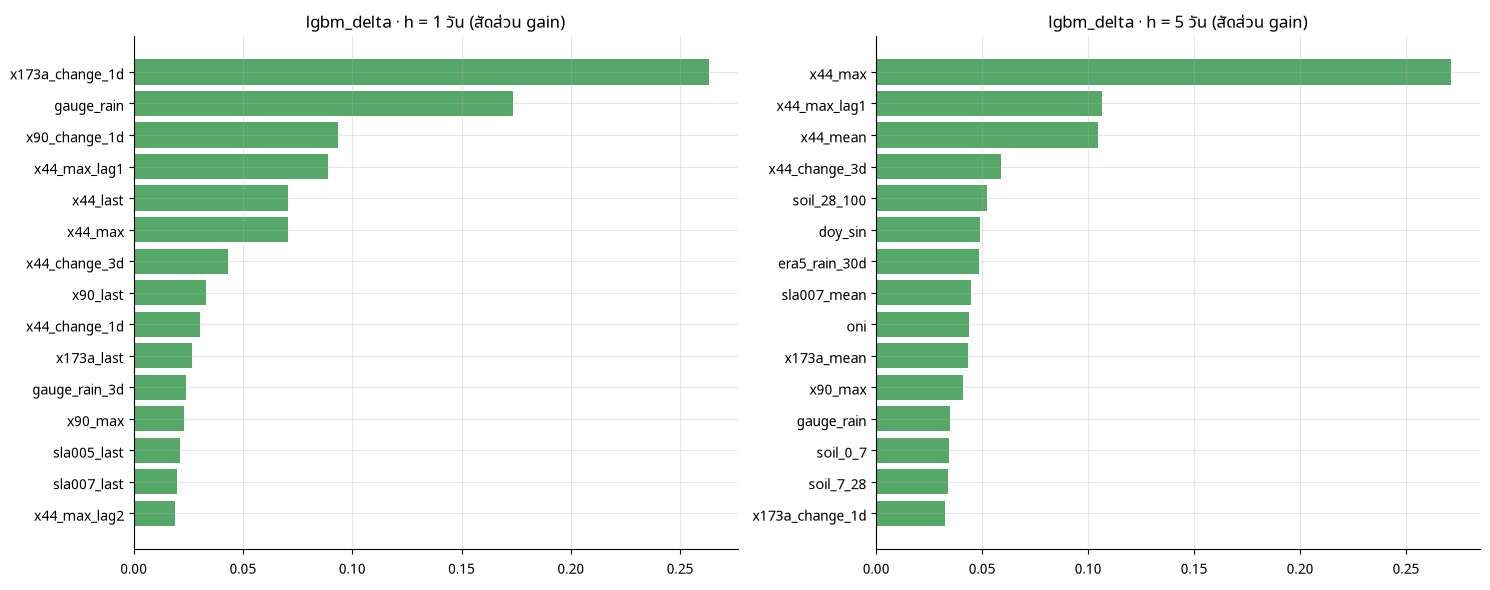

,h=1,h=5
x44_last,0.575,0.278
x173a_mean,-0.552,-0.419
x44_max,-0.501,-0.641
x90_mean,-0.390,-0.107
x173a_last,0.302,0.393
x173a_max,0.296,0.031
x44_max_lag1,-0.270,-0.036
x90_last,0.270,0.068
x90_max,0.149,-0.115
gauge_rain,0.123,0.096


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, h in zip(axes, (1, 5)):
    importance = fitted[("lgbm_delta", h)].feature_importance().head(15)
    ax.barh(importance.index[::-1], importance.values[::-1] / importance.sum(), color=MODEL_COLORS["lgbm_delta"])
    ax.set_title(f"lgbm_delta · h = {h} วัน (สัดส่วน gain)")
plt.tight_layout()
plt.show()

coefficients = pandas.DataFrame({f"h={h}": fitted[("ridge_delta", h)].feature_importance() for h in (1, 5)})
coefficients.reindex(coefficients["h=1"].abs().sort_values(ascending=False).index).head(12).round(3)

## 5 · เพดานความแม่นยำ: ถ้ารู้ฝนในอนาคตแม่นยำ 100%
เพิ่ม `oracle_rain_next1..hd` (ฝนที่ตกจริงในอนาคต) เข้าไปเป็น feature — **ทำไม่ได้ในชีวิตจริง**
แต่บอกได้ว่า ถ้ามีพยากรณ์ฝนที่ดี โมเดลจะดีขึ้นได้แค่ไหน และความผิดพลาดของการทำนาย 3–5 วันมาจากการไม่รู้ฝนล่วงหน้าหรือไม่

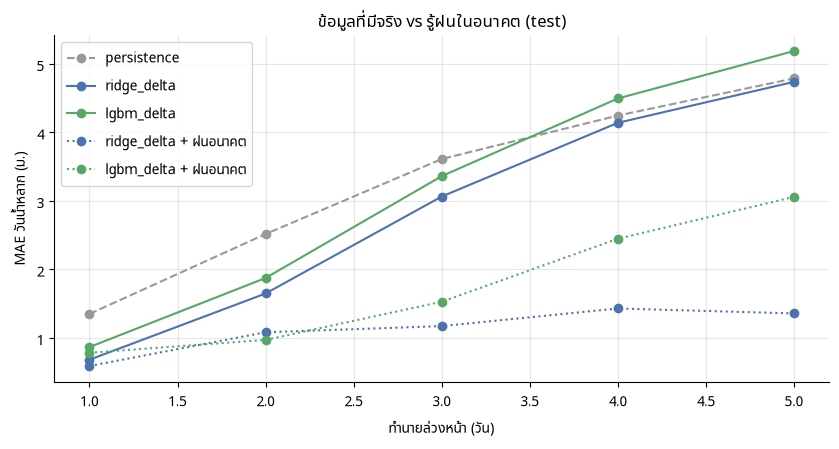

h,1,2,3,4,5
model,,,,,
lgbm_delta,0.86,1.87,3.36,4.49,5.18
lgbm_delta + ฝนอนาคต,0.78,0.97,1.53,2.44,3.06
persistence,1.35,2.51,3.61,4.24,4.78
ridge_delta,0.68,1.65,3.06,4.14,4.73
ridge_delta + ฝนอนาคต,0.59,1.08,1.17,1.43,1.35


In [9]:
oracle_rows = []
for h in features.HORIZONS:
    oracle_features = FEATURES + [f"oracle_rain_next{k}d" for k in range(1, h + 1)]
    for name in ["ridge_delta", "lgbm_delta"]:
        _, prediction = fit_and_predict(name, BEST_PARAMS[name], train_validation, test, h, oracle_features)
        oracle_rows.append({"model": f"{name} + ฝนอนาคต", "h": h, **scores(prediction, test, h)})
oracle = pandas.DataFrame(oracle_rows)

comparison = pandas.concat([results[results["model"].isin(["persistence", "ridge_delta", "lgbm_delta"])], oracle])
pivot = comparison.pivot(index="h", columns="model", values="MAE วันน้ำหลาก")

fig, ax = plt.subplots(figsize=(10, 4.5))
styles = {
    "persistence": ("#999999", "--"), "ridge_delta": ("#4c72b0", "-"), "lgbm_delta": ("#55a868", "-"),
    "ridge_delta + ฝนอนาคต": ("#4c72b0", ":"), "lgbm_delta + ฝนอนาคต": ("#55a868", ":"),
}
for name, (color, style) in styles.items():
    ax.plot(pivot.index, pivot[name], color=color, ls=style, marker="o", label=name)
ax.set_xlabel("ทำนายล่วงหน้า (วัน)")
ax.set_ylabel("MAE วันน้ำหลาก (ม.)")
ax.set_title("ข้อมูลที่มีจริง vs รู้ฝนในอนาคต (test)")
ax.legend()
plt.show()
pivot.round(2).T

## 6 · เทรนโมเดลสุดท้ายบนข้อมูลทั้งหมดและบันทึก
สำหรับ POC / หน้าเว็บ: ใช้ทุกปีรวมเหตุการณ์ 2568 เพื่อให้โมเดลเคยเห็นน้ำท่วมจริง
บันทึกเป็น `data/models/x44_<model>_h{1..5}.joblib` + manifest `.json`
และ `uncertainty.json` = RMSE บน test ต่อ horizon แยกตามระดับที่โมเดลทำนาย (< 4 ม. / ≥ 4 ม.) ใช้เป็นความไม่แน่นอนของการพยากรณ์ในแผนที่ notebook 05

In [10]:
everything = table.dropna(subset=["x44_max"])
saved = []
for name in ["ridge_delta", "lgbm_delta"]:
    final_models = [
        models.HorizonModel(name, h, FEATURES, BEST_PARAMS[name]).fit(everything)
        for h in features.HORIZONS
    ]
    saved.append(models.save(final_models, f"x44_{name}"))
for path in saved:
    print("saved", path.relative_to(config.ROOT))

# Forecast uncertainty for the flood map, measured on test before the final
# refit. Errors are far larger when the model itself forecasts high water, so
# the RMSE is split by the forecast stage, which is known at forecast time
import json
uncertainty = {"split_stage_m": HIGH_WATER_M}
for name in ["ridge_delta", "lgbm_delta"]:
    uncertainty[name] = {}
    for h in features.HORIZONS:
        uncertainty[name][h] = evaluation.stage_split_rmse(predictions[(name, h)], test, h)
(models.MODELS_DIR / "uncertainty.json").write_text(json.dumps(uncertainty, indent=2))
pandas.DataFrame({
    (name, part): {h: uncertainty[name][h][part] for h in features.HORIZONS}
    for name in ["ridge_delta", "lgbm_delta"] for part in ("low", "high", "high_days")
}).rename_axis("h")

saved data/models/x44_ridge_delta.json
saved data/models/x44_lgbm_delta.json


ridge_delta                  lgbm_delta                 
          low   high high_days        low   high high_days
h                                                         
1       0.171  0.811         8      0.181  0.933         9
2       0.271  1.954         9      0.288  1.940         9
3       0.402  2.932         8      0.414  3.130         9
4       0.574  3.112         6      0.637  3.110         6
5       0.678  3.619         5      0.765  3.160         5

## สรุป

### ผลบน test (2025–2026, มีน้ำท่วม พ.ย. 2568)
| ล่วงหน้า | persistence | ridge_delta | lgbm_delta | lgbm_linear_delta | lgbm_level |
|---|---|---|---|---|---|
| 1 วัน | 1.35 | 0.68 | 0.86 | **0.63** | 2.47 |
| 2 วัน | 2.51 | **1.65** | 1.87 | 1.66 | 2.80 |
| 3 วัน | 3.61 | 3.06 | 3.36 | **2.96** | 3.91 |
| 5 วัน | 4.78 | **4.73** | 5.18 | 5.27 | 5.68 |

(MAE วันน้ำหลาก หน่วย ม.)

1. **ล่วงหน้า 1–2 วันใช้ได้จริง** — คลาดเคลื่อนลดลงครึ่งหนึ่งจาก persistence ที่ h=1 และ ~35% ที่ h=2
   เตือนระดับ ≥ 7.40 ม. ถูก 4–5 จาก 6 วันล่วงหน้า 1 วัน โดยไม่มีเตือนผิด
   (persistence ที่ดู "เตือนถูก" คือวันที่ท่วมอยู่แล้ว — มันเตือนได้หลังน้ำท่วมแล้วเท่านั้น และเตือนผิดตอนน้ำลด)
2. **ล่วงหน้า 3–5 วันยังไม่ดีกว่า persistence** และไม่มีโมเดลไหนเตือนได้ — feature ที่มีบอกได้แค่ว่า "น้ำต้นน้ำกำลังขึ้น" ซึ่งรู้ล่วงหน้าไม่ถึง 1 วัน
3. **LightGBM ที่ทำนายระดับตรงๆ ติดเพดาน ~6 ม.** (ไม่เคยเห็นน้ำสูงกว่านี้ตอน train) — ยืนยันปัญหาจาก notebook 03
   การเปลี่ยนเป็นทำนาย **การเปลี่ยนแปลง** แก้ปัญหานี้ได้ โมเดลแบบ delta ทำนายถึง ~10 ม. ได้
4. **feature สำคัญ:** h=1 ใช้การขึ้นของน้ำต้นน้ำ (X.173A, X.90) และฝนสถานีในเมือง ส่วน h=5 แทบใช้แค่ระดับวันนี้ ความชื้นในดิน และฤดูกาล
5. **ถ้ารู้ฝนในอนาคต:** ridge ที่ h=5 คลาดเคลื่อนลดจาก 4.73 → 1.35 ม. (ดีขึ้น ~3.5 เท่า)
   → **ตัวแปรที่ขาดสำหรับการทำนาย 3–5 วันคือพยากรณ์ฝน**

### เลือกใช้ใน POC
- **ridge_delta** เป็นโมเดลหลัก: ดีที่สุดบน validation, ง่าย, อธิบายได้, ทำนายเกินช่วง train ได้
- **lgbm_delta** เก็บไว้เทียบในรายงานตามข้อเสนอโครงงาน (XGBoost/LightGBM baseline)
- ทั้งคู่เทรนใหม่บนข้อมูลทั้งหมดและบันทึกใน `data/models/`

### ขั้นถัดไป
- เพิ่ม **พยากรณ์ฝนจริงในอดีต** จาก Open-Meteo Historical Forecast / Previous Runs (GFS ตั้งแต่ 2021, ECMWF ตั้งแต่ 2024) เป็น feature
  ความแม่นจะอยู่ระหว่างเส้น "ข้อมูลที่มีจริง" กับ "รู้ฝนในอนาคต" — พยากรณ์ฝนปี 2568 ต่ำกว่าจริงมาก จึงไม่ควรคาดหวังถึงเพดาน
- ขยายชุด train ด้วยเหตุการณ์ 2543 / 2553 ผ่าน ERA5 + GloFAS (ยังไม่มีระดับน้ำรายวันช่วงนั้น)
- LSTM เทียบกับ baseline นี้ (หัวข้อ 4.2 ในข้อเสนอโครงงาน)
- ต่อเข้ากับ heatmap รายโซน (notebook 05)